# Validate the Python world-camera reconstruction pipeline

Load every example world-camera measurement, run both MATLAB `reconstructionPipeline` and Python `world_transformation_pipeline`, and quantify their numerical agreement. The notebook uses one MATLAB Engine session for the complete validation run.

In [1]:
# Import the Python libraries used for paths, numerical calculations, tables, plotting,
# MATLAB-file loading, and communication with MATLAB.
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import matlab.engine


# First, define some paths we are going to reuse

PROJECT_ROOT: Path = Path("/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis")
CODE_ROOT: Path = PROJECT_ROOT / "code"
EXAMPLE_DATA_DIR: Path = PROJECT_ROOT / "data" / "exampleWorldCameraImages"
SENSOR_UTILITY_DIR: Path = CODE_ROOT / "library" / "sensor_utility"

# Add our sensor utility folder to Python's module search path so world_util can be imported.
sys.path.append(str(SENSOR_UTILITY_DIR))
import world_util

print(f"Project root: {PROJECT_ROOT}")

/opt/anaconda3/lib/python3.13/site-packages/matlabengine-25.2-py3.13.egg/matlab/__init__.py:158: UserWarning: Python versions 3.9, 3.10, 3.11, and 3.12 are supported, but your version of Python is 3_13
  warnings.warn('Python versions 3.9, 3.10, 3.11, and 3.12 are supported, but your version of Python is %s' % _version)
/opt/anaconda3/lib/python3.13/site-packages/matlabengine-25.2-py3.13.egg/matlab/engine/__init__.py:43: UserWarning: MATLAB Engine for Python supports Python version 3.9, 3.10, 3.11, and 3.12, but your version of Python is 3_13
  warnings.warn('MATLAB Engine for Python supports Python version'


Project root: /Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis


In [2]:
# Next, let's load in the measurements
# glob finds every example MAT file whose name contains _AGCandMS_. Sorting the
# paths makes the processing and output order reproducible.
measurement_paths: list[Path] = sorted(EXAMPLE_DATA_DIR.glob("*_AGCandMS_*.mat"))
if not measurement_paths:
    raise FileNotFoundError(f"No example measurements found in {EXAMPLE_DATA_DIR}")

print(f"Found {len(measurement_paths)} measurements:")
for measurement_path in measurement_paths:
    print(f"  {measurement_path.name}")

Found 7 measurements:
  indoor_AGCandMS_01.mat
  indoor_AGCandMS_02.mat
  indoor_AGCandMS_03.mat
  outdoor_AGCandMS_01.mat
  outdoor_AGCandMS_02.mat
  outdoor_AGCandMS_03.mat
  planetarium_AGCandMS_01.mat


In [3]:
def compare_pipeline_results(
    measurement_name: str,
    matlab_radiance: np.ndarray,
    python_radiance: np.ndarray,
    imputed_mask: np.ndarray,
) -> tuple[dict[str, object], np.ndarray]:
    """Calculate finite-value errors and compare non-finite masks."""

    # If the shape is not equal, this is a huge serious error 
    if matlab_radiance.shape != python_radiance.shape:
        raise ValueError(
            f"Shape mismatch for {measurement_name}: MATLAB {matlab_radiance.shape}, "
            f"Python {python_radiance.shape}."
        )

    # Find the finite pixels in both images
    finite_in_both: np.ndarray = np.isfinite(matlab_radiance) & np.isfinite(python_radiance)

    # Allocate an array for the absolute error between the images
    absolute_error: np.ndarray = np.full(matlab_radiance.shape, np.nan, dtype=np.float64)

    # Find the absolute error of the finite pixels
    absolute_error[finite_in_both] = np.abs(
        python_radiance[finite_in_both] - matlab_radiance[finite_in_both]
    )

    # Relative error requires division by the MATLAB result. Exclude zero-valued
    # MATLAB pixels so that this calculation does not divide by zero.
    relative_denominator: np.ndarray = finite_in_both & (matlab_radiance != 0)
    relative_error: np.ndarray = absolute_error[relative_denominator] / np.abs(
        matlab_radiance[relative_denominator]
    )
    # Pull the valid absolute errors into a one-dimensional vector so summary
    # statistics can be calculated without the NaNs used in the error image.
    finite_absolute_error: np.ndarray = absolute_error[finite_in_both]

    # Separate the pixels the sensor actually measured from the ones the
    # imputation stage invented. Only the measured pixels can be expected to
    # match exactly, so only they are held to a strict tolerance here. The
    # imputed pixels are reported on their own further down the notebook.
    measured_pixels: np.ndarray = finite_in_both & ~imputed_mask

    metrics: dict[str, object] = {
        "measurement": measurement_name,
        "imputed_pixels": int(np.count_nonzero(imputed_mask)),
        "mean_absolute_error": float(np.mean(finite_absolute_error)),
        "max_absolute_error": float(np.max(finite_absolute_error)),
        "max_relative_error": float(np.max(relative_error)) if relative_error.size else 0.0,
        # Both implementations must classify exactly the same pixels as
        # saturated or undefined.
        "non_finite_masks_equal": bool(
            np.array_equal(np.isinf(matlab_radiance), np.isinf(python_radiance))
            and np.array_equal(np.isnan(matlab_radiance), np.isnan(python_radiance))
        ),
        # The real pass criterion: where the sensor measured light, the two
        # implementations must agree to floating-point precision.
        "measured_pixels_allclose": bool(
            np.allclose(
                python_radiance[measured_pixels],
                matlab_radiance[measured_pixels],
                rtol=1e-12,
                atol=0.0,
            )
        ),
    }
    return metrics, absolute_error

In [4]:
# Store one metrics row and the image outputs for every measurement.
comparison_rows: list[dict[str, object]] = []
comparison_outputs: dict[str, dict[str, np.ndarray]] = {}

# Start MATLAB only once. tbUseProject activates lightLoggerAnalysis and adds
# the project plus its configured toolbox dependencies to the MATLAB path.
matlab_engine: object = matlab.engine.start_matlab()
matlab_engine.tbUseProject("lightLoggerAnalysis", nargout=0)

try:
    for measurement_path in measurement_paths:
        # Load the same three variables used by demoProcessingStages.m.
        # variable_names prevents scipy from loading unrelated variables from the file.
        # simplify_cells=True converts MATLAB structs/cells into simpler Python dict/list
        # objects and removes singleton dimensions. In particular, AGCSettings becomes
        # a normal dictionary instead of a nested one-element structured NumPy array.
        python_data: dict[str, object] = scipy.io.loadmat(
            measurement_path,
            variable_names=["worldFrame", "AGCSettings", "minispectValue"],
            simplify_cells=True,
        )
        # Convert the raw world frame explicitly to a NumPy array. Extract each AGC
        # setting from the simplified MATLAB struct and convert it to a Python float.
        world_frame: np.ndarray = np.asarray(python_data["worldFrame"])
        matlab_agc_settings: dict[str, object] = python_data["AGCSettings"]
        agc_settings: dict[str, float] = {
            "exposure": float(np.asarray(matlab_agc_settings["exposure"]).squeeze()),
            "Again": float(np.asarray(matlab_agc_settings["Again"]).squeeze()),
            "Dgain": float(np.asarray(matlab_agc_settings["Dgain"]).squeeze()),
        }
        # This pipeline comparison does not consume minispectValue, but loading it here
        # keeps the notebook's input behavior aligned with demoProcessingStages.m.
        minispect_value: object = python_data["minispectValue"]

        # MATLAB loads and processes its native variables without a Python
        # conversion round trip. minispectValue is loaded for parity with
        # demoProcessingStages, although reconstructionPipeline does not use it.
        # engine.load returns the requested MATLAB variables in a Python dictionary.
        # nargout=1 tells MATLAB Engine to return that dictionary to Python.
        matlab_data: dict[str, object] = matlab_engine.load(
            str(measurement_path),
            "worldFrame",
            "AGCSettings",
            "minispectValue",
            nargout=1,
        )
        # Run the MATLAB reference function with its native uint8 frame and struct.
        # Convert the returned MATLAB matrix to a float64 NumPy array for comparison.
        matlab_radiance: np.ndarray = np.asarray(
            matlab_engine.reconstructionPipeline(
                matlab_data["worldFrame"], matlab_data["AGCSettings"], nargout=1
            ),
            dtype=np.float64,
        )
        # Run the Python implementation on the same frame and camera settings.
        python_radiance: np.ndarray = world_util.world_transformation_pipeline(
            world_frame, agc_settings
        )

        # Calculate this measurement's errors, retain its images for visualization,
        # and print a short progress result immediately.
        # Recover which pixels the imputation stage replaced. A pixel is
        # imputed when linearization marked it Inf (it hit the sensor ceiling)
        # or zero (it sat on the floor).
        linearized_frame: np.ndarray = world_util.linearize_camera_responsivity(
            world_frame.astype(np.float64).copy()
        )
        imputed_mask: np.ndarray = np.isinf(linearized_frame) | (linearized_frame == 0)

        metrics, absolute_error = compare_pipeline_results(
            measurement_path.name, matlab_radiance, python_radiance, imputed_mask
        )
        comparison_rows.append(metrics)
        comparison_outputs[measurement_path.name] = {
            "world_frame": world_frame,
            "matlab_radiance": matlab_radiance,
            "python_radiance": python_radiance,
            "absolute_error": absolute_error,
        }
# Always close MATLAB, even if loading or processing one measurement raises an error.
finally:
    matlab_engine.quit()

Locating project "lightLoggerAnalysis" within "/Users/zacharykelly/Documents/MATLAB/projects".


  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".


Local copy of ToolboxToolbox out of date (or you made local modifications).
Consider updating with git pull or otherwise synchronizing.



Updating "ToolboxRegistry".


Already up to date.
Updating "lightLoggerAnalysis".


...

  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".



FLIC_processing_dir = 

    "/Volumes/FLIC_processing"

  Hook success with status 0.
Checking for "combiLEDToolbox" local hook.
  Running local hook "/Users/zacharykelly/Documents/MATLAB/localHookFolder/combiLEDToolboxLocalHook.m".


  Hook success with status 0.
Checking for "BrainardLabToolbox" local hook.
Checking for "WatsonYellott2012_PupilSize" local hook.
Checking for "bads" local hook.
Checking for "export_fig" local hook.


Checking for "Psychtoolbox-3" local hook.
Checking for "SilentSubstitutionToolbox" local hook.
Checking for "ExampleTestToolbox" local hook.


Error: "BrainardLabToolbox" had status 1, message "Your configuration specifies to merge with the ref 'refs/heads/master'
from the remote, but no such ref was fetched."
Something went wrong with resolved toolboxes, please see above.


### Final radiance map

`max_relative_error` below is driven entirely by the imputed pixels, where exact
agreement is not achievable, so it is reported rather than asserted. The pass
criterion is `measured_pixels_allclose`: at every pixel the sensor actually
measured, the two implementations must agree to `rtol=1e-12`. See the closing
section of this notebook for why the imputed pixels are treated differently.

In [5]:
# Combine the per-measurement dictionaries into one table and restore filename order.
comparison_table: pd.DataFrame = pd.DataFrame(comparison_rows).sort_values("measurement").reset_index(drop=True)

# Display error values as ordinary decimals instead of scientific notation.
error_columns: list[str] = [
    "mean_absolute_error", "max_absolute_error", "max_relative_error"
]
display(comparison_table.style.format({column: "{:.20f}" for column in error_columns}))

# Both implementations must agree on which pixels are non-finite, and must
# agree to floating-point precision everywhere the sensor measured light.
assert comparison_table["non_finite_masks_equal"].all(), "A measurement disagrees on its Inf or NaN mask."
assert comparison_table["measured_pixels_allclose"].all(), "A measured pixel differs by more than the tolerance."
print("Every measured pixel agrees with MATLAB to within rtol=1e-12.")

,measurement,imputed_pixels,mean_absolute_error,max_absolute_error,max_relative_error,non_finite_masks_equal,measured_pixels_allclose
0,indoor_AGCandMS_01.mat,13990,0.00000080695612073954,0.01596628667325111772,0.46126252451072058403,True,True
1,indoor_AGCandMS_02.mat,34821,0.00000000468116322227,0.00005190541537318505,0.19088992762776907375,True,True
2,indoor_AGCandMS_03.mat,90674,0.00000001735080607380,0.00005811973383866901,0.10637411751456986309,True,True
3,outdoor_AGCandMS_01.mat,29609,0.00016599632096318993,0.36669850630908484845,0.11837518531937896160,True,True
4,outdoor_AGCandMS_02.mat,27096,0.00020982197510047230,1.91310225848108039770,0.17135714231395965390,True,True
5,outdoor_AGCandMS_03.mat,74498,0.00050672097682049277,0.41414722336762821442,0.11116206038994309868,True,True
6,planetarium_AGCandMS_01.mat,0,0.00000000000000004354,0.00000000000000006939,0.00000000000000435975,True,True


Every measured pixel agrees with MATLAB to within rtol=1e-12.


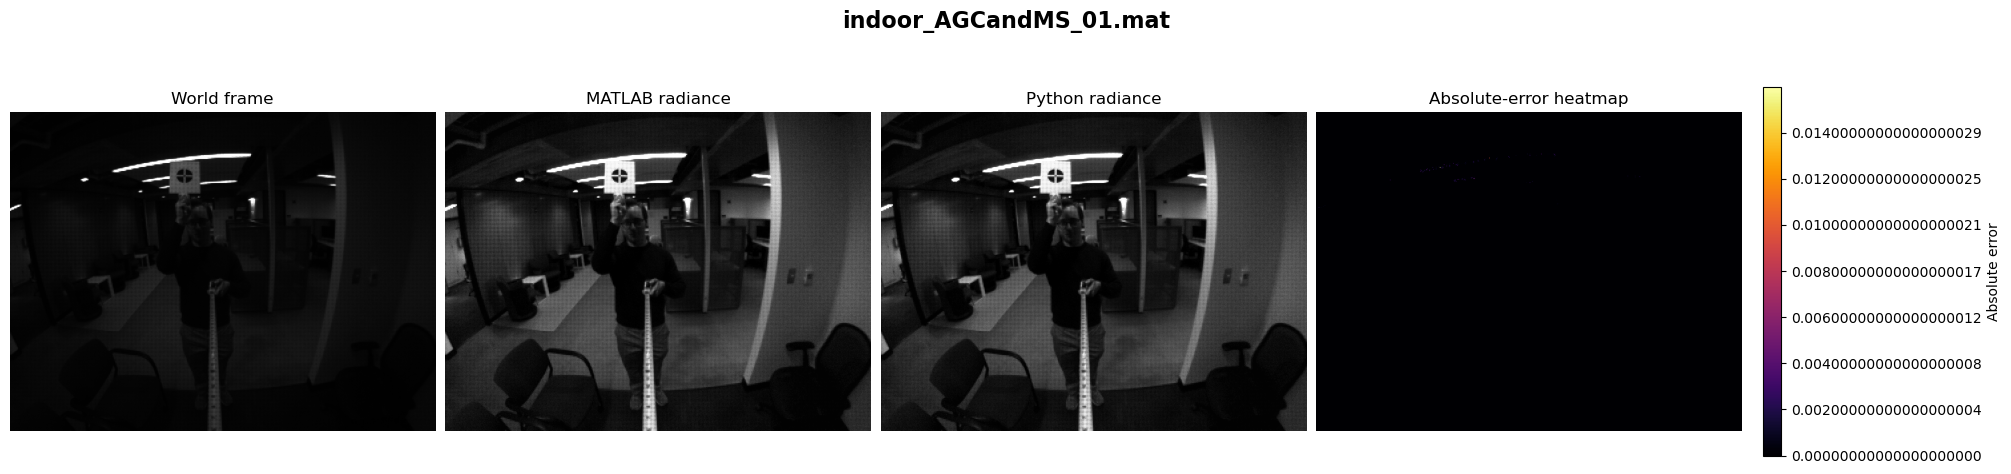

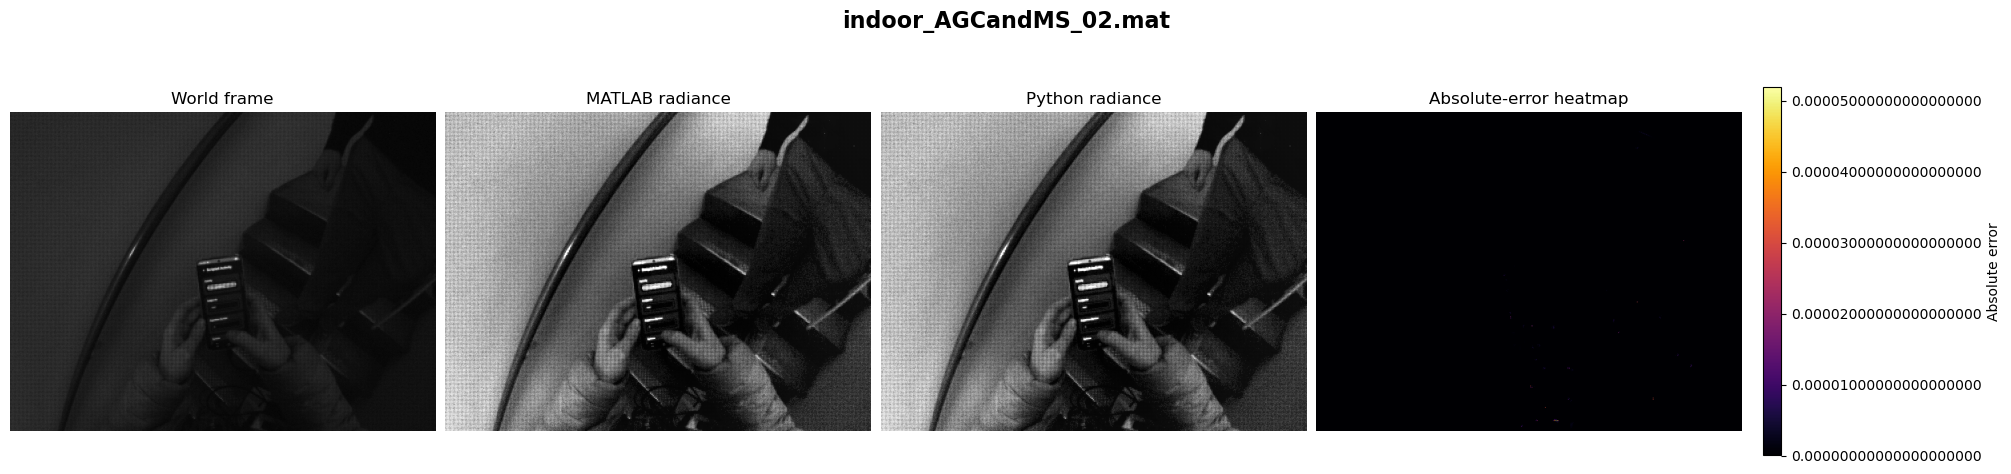

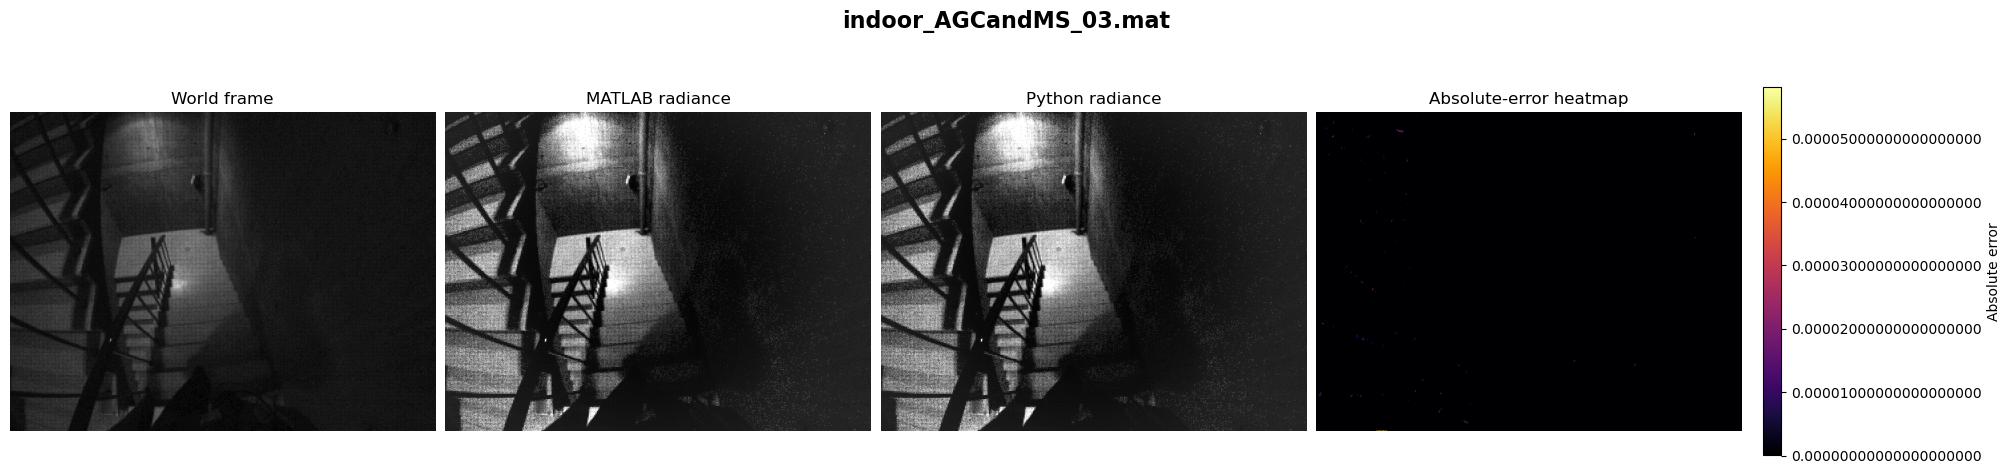

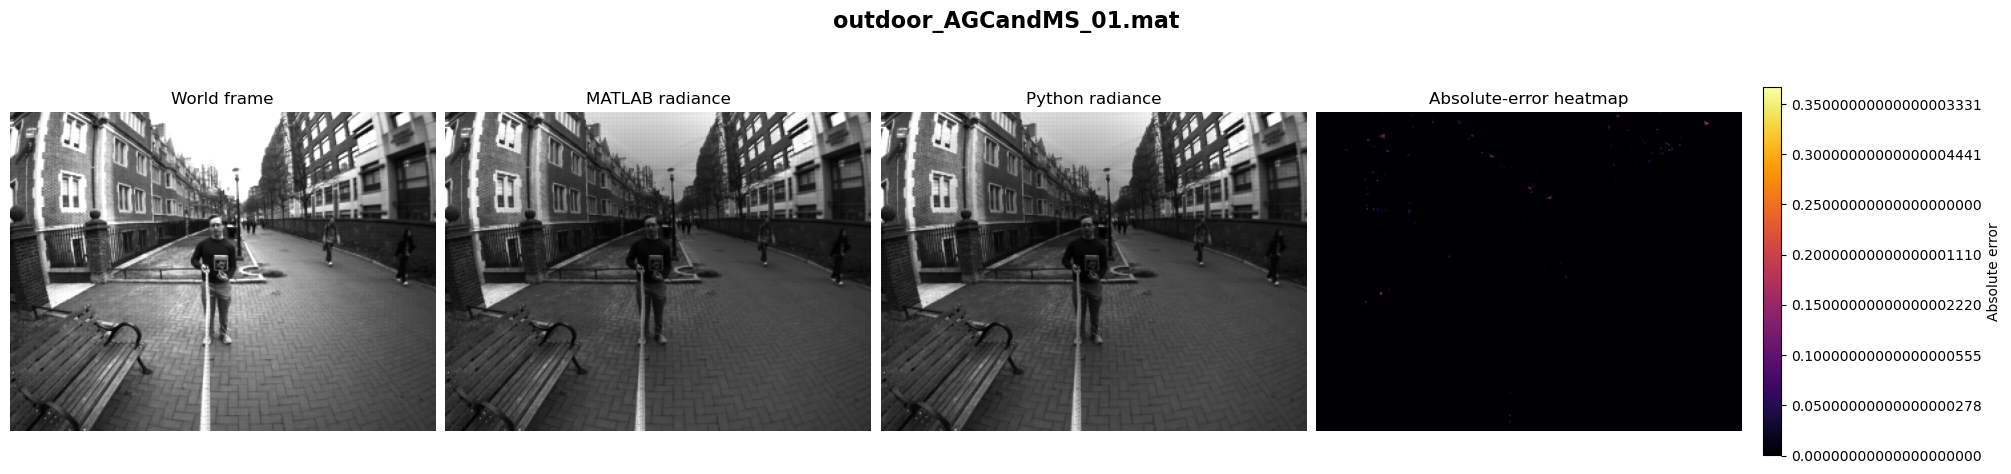

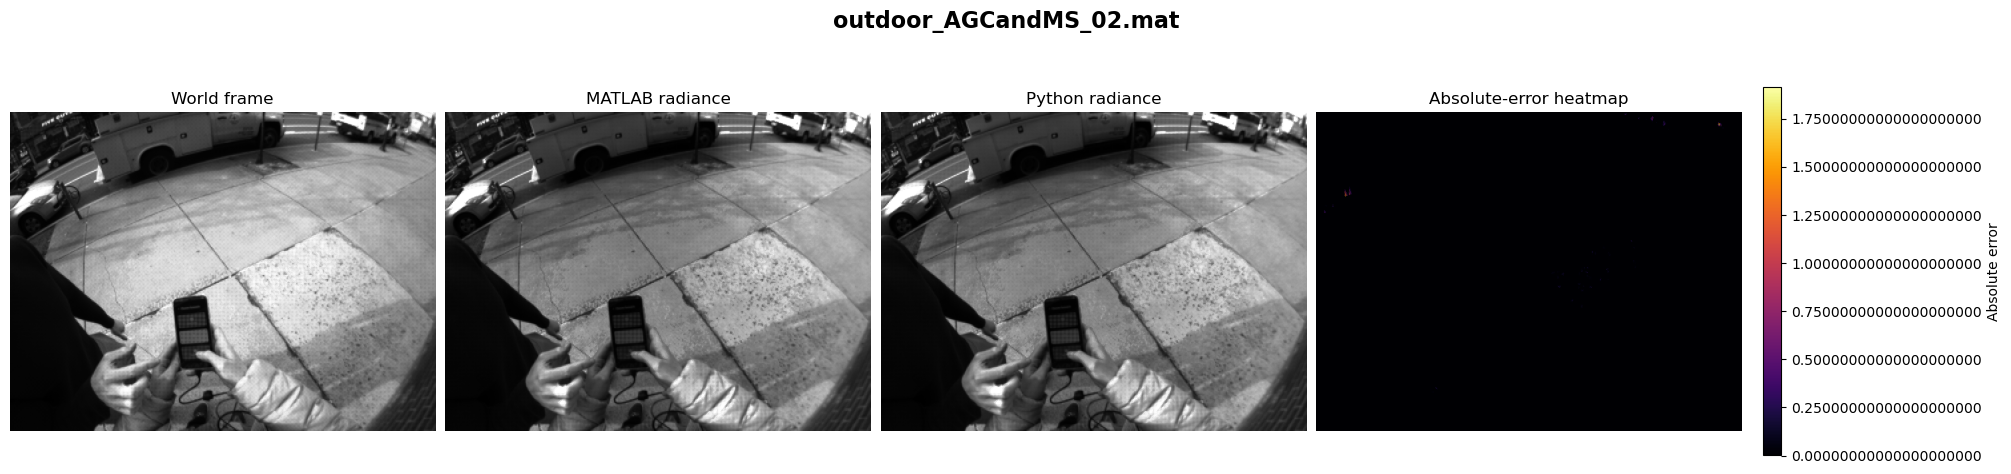

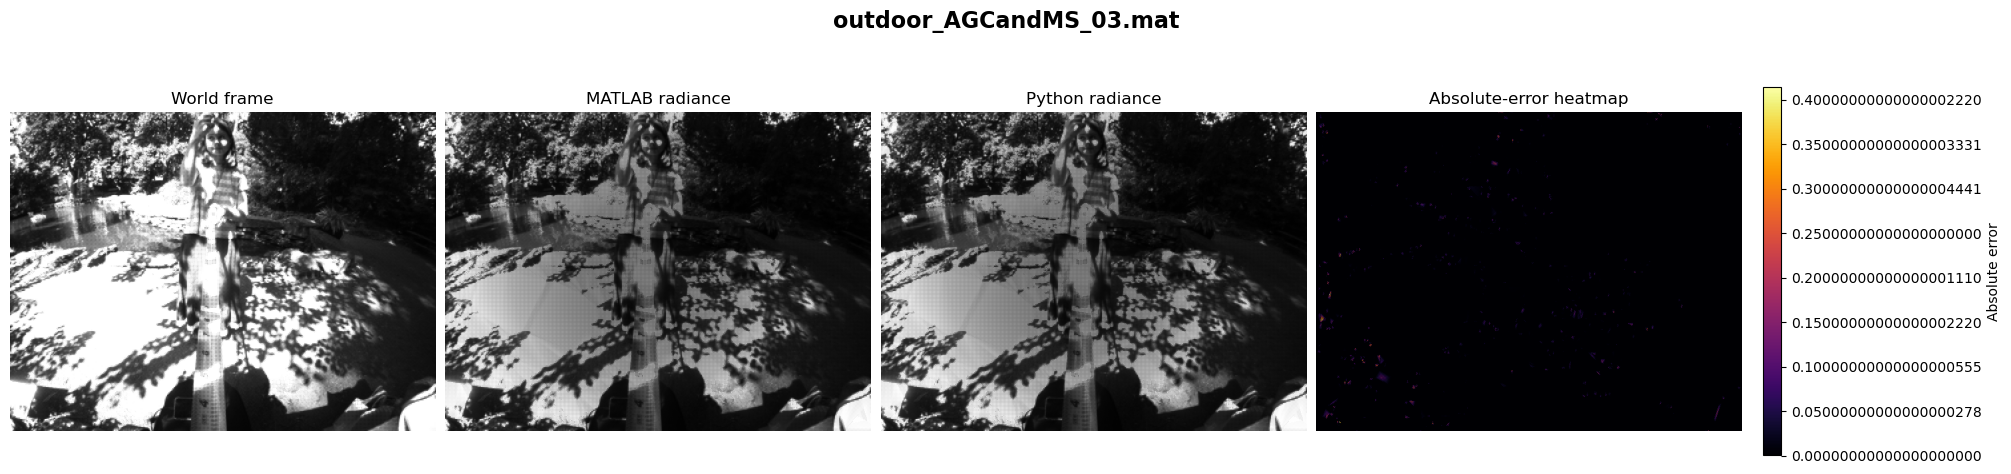

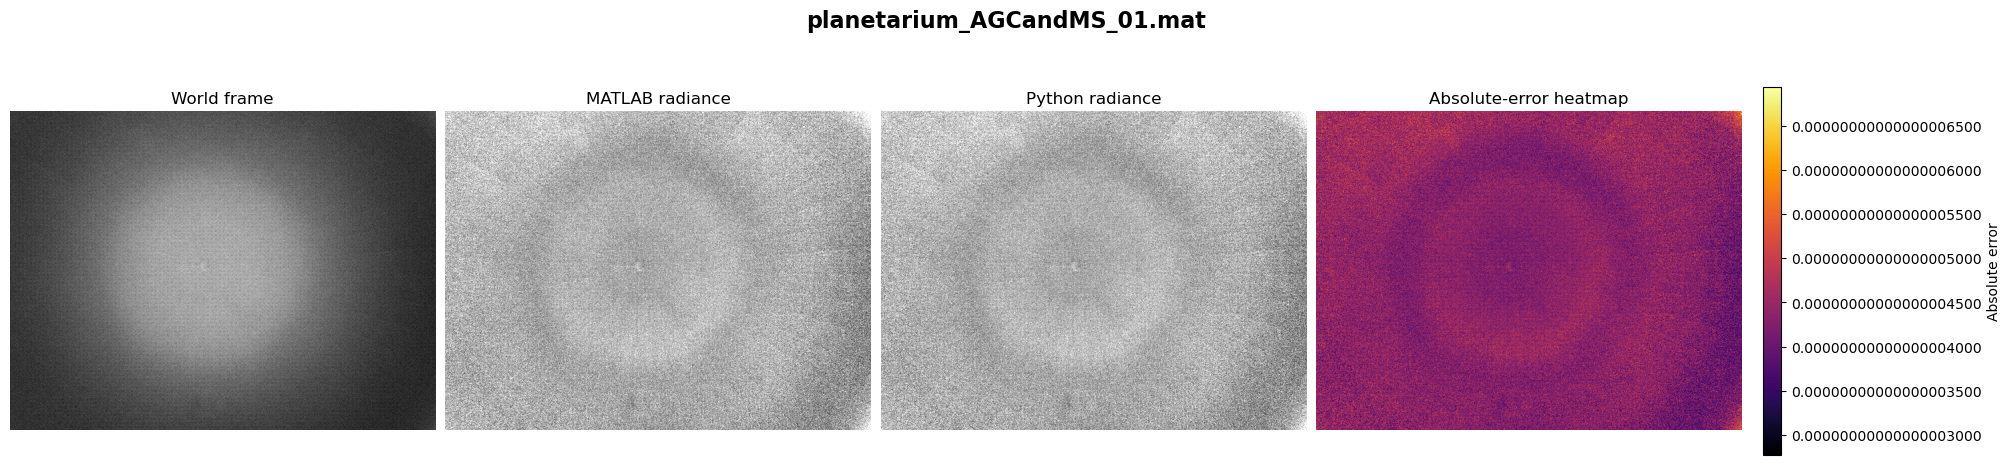

In [6]:
from matplotlib.ticker import FuncFormatter

# Create one 1-by-4 comparison figure for every measurement.
for measurement_path in measurement_paths:
    measurement_name: str = measurement_path.name
    output: dict[str, np.ndarray] = comparison_outputs[measurement_name]

    world_frame: np.ndarray = output["world_frame"]
    matlab_radiance: np.ndarray = output["matlab_radiance"]
    python_radiance: np.ndarray = output["python_radiance"]
    absolute_error: np.ndarray = output["absolute_error"]

    # Use the same display range for both radiance images so their brightness
    # and contrast can be compared directly. Ignore Inf and NaN when finding it.
    finite_radiance_values: np.ndarray = np.concatenate([
        matlab_radiance[np.isfinite(matlab_radiance)],
        python_radiance[np.isfinite(python_radiance)],
    ])
    radiance_min: float = float(np.min(finite_radiance_values))
    radiance_max: float = float(np.percentile(finite_radiance_values, 99))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
    fig.suptitle(measurement_name, fontsize=16, fontweight="bold")

    axes[0].imshow(world_frame, cmap="gray")
    axes[0].set_title("World frame")

    axes[1].imshow(
        np.ma.masked_invalid(matlab_radiance),
        cmap="gray",
        vmin=radiance_min,
        vmax=radiance_max,
    )
    axes[1].set_title("MATLAB radiance")

    axes[2].imshow(
        np.ma.masked_invalid(python_radiance),
        cmap="gray",
        vmin=radiance_min,
        vmax=radiance_max,
    )
    axes[2].set_title("Python radiance")

    # Display the absolute MATLAB-versus-Python difference as a heatmap.
    error_heatmap = axes[3].imshow(
        np.ma.masked_invalid(absolute_error), cmap="inferno"
    )
    axes[3].set_title("Absolute-error heatmap")
    error_colorbar = fig.colorbar(error_heatmap, ax=axes[3], shrink=0.8)
    error_colorbar.set_label("Absolute error")
    error_colorbar.ax.yaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"{value:.20f}")
    )

    for axis in axes:
        axis.axis("off")

    plt.show()

## Validate the remaining pipeline stages

The comparison above checks the final radiance map. The cells below extend the
validation to the pieces that `reconstructionPipeline` either derives internally
or leaves to a separate function:

1. the derived saturation threshold,
2. every intermediate stage of the reconstruction,
3. the floor/ceiling imputation considered on its own,
4. `demosaicRadianceMapRCD`, and
5. buffered `(frames, rows, cols)` inputs, which have no MATLAB counterpart.

One MATLAB Engine session serves all of them.

In [7]:
# Collect every extra comparison in one MATLAB session. The helper below mirrors
# the summary statistics used for the final radiance map, but it reports the
# median and 99th percentile in addition to the maximum. The imputation stage
# disagrees on a small number of pixels for a structural reason described at the
# end of this notebook, so a single maximum would hide how tightly the two
# implementations actually agree.
def summarize_agreement(
    label: str,
    matlab_values: np.ndarray,
    python_values: np.ndarray,
    restrict_to: np.ndarray | None = None,
) -> dict[str, object]:
    """Summarize the relative agreement between two arrays of the same shape."""

    if matlab_values.shape != python_values.shape:
        raise ValueError(
            f"Shape mismatch for {label}: MATLAB {matlab_values.shape}, "
            f"Python {python_values.shape}."
        )

    # Only pixels that are finite in both results can be compared numerically.
    comparable: np.ndarray = np.isfinite(matlab_values) & np.isfinite(python_values)

    # Some comparisons are only meaningful over a subset, such as the pixels
    # that the imputation stage actually replaced.
    if restrict_to is not None:
        comparable = comparable & restrict_to

    absolute_error: np.ndarray = np.abs(
        python_values[comparable] - matlab_values[comparable]
    )
    # Guard the division so that a zero-valued MATLAB pixel cannot produce a NaN.
    relative_error: np.ndarray = absolute_error / np.maximum(
        np.abs(matlab_values[comparable]), np.finfo(np.float64).tiny
    )

    return {
        "comparison": label,
        "median_relative_error": float(np.median(relative_error)) if relative_error.size else 0.0,
        "p99_relative_error": float(np.percentile(relative_error, 99)) if relative_error.size else 0.0,
        "max_relative_error": float(np.max(relative_error)) if relative_error.size else 0.0,
        "max_absolute_error": float(np.max(absolute_error)) if absolute_error.size else 0.0,
        # A disagreement here would mean the two implementations classify
        # different pixels as saturated or undefined.
        "non_finite_masks_equal": bool(
            np.array_equal(np.isinf(matlab_values), np.isinf(python_values))
            and np.array_equal(np.isnan(matlab_values), np.isnan(python_values))
        ),
    }

In [8]:
# Run the extended validation. Rows are collected per comparison so that each
# section below can render its own table.
saturation_threshold_row: dict[str, object] = {}
stage_rows: list[dict[str, object]] = []
imputation_rows: list[dict[str, object]] = []
demosaic_rows: list[dict[str, object]] = []

extended_engine: object = matlab.engine.start_matlab()
extended_engine.tbUseProject("lightLoggerAnalysis", nargout=0)

try:
    # --- 1. The derived saturation threshold ------------------------------
    # reconstructionPipeline derives this threshold inline from the clipping
    # exponent and the dark signal, so recompute it in MATLAB the same way and
    # compare it against the Python helper.
    # Load the two derived parameters into the MATLAB workspace and recompute
    # the threshold with the same expression reconstructionPipeline uses.
    extended_engine.eval(
        "clippingExponent = load(fullfile(tbLocateProjectSilent('lightLoggerAnalysis'),"
        "'derived','nonLinearClippingExponent.mat')).clippingExponent;",
        nargout=0,
    )
    extended_engine.eval(
        "darkSignal = load(fullfile(tbLocateProjectSilent('lightLoggerAnalysis'),"
        "'derived','darkSignal.mat')).darkSignal;",
        nargout=0,
    )
    matlab_saturation_threshold: int = int(
        extended_engine.eval(
            "floor((2^8 - 1 - darkSignal) * "
            "(1 - 4.0^(-(clippingExponent / (clippingExponent + 1))))"
            "^(1/clippingExponent) + darkSignal)",
            nargout=1,
        )
    )
    python_saturation_threshold: int = world_util.calculate_world_saturation_threshold()
    saturation_threshold_row = {
        "matlab_threshold": matlab_saturation_threshold,
        "python_threshold": python_saturation_threshold,
        "equal": matlab_saturation_threshold == python_saturation_threshold,
    }

    for measurement_path in measurement_paths:
        python_data: dict[str, object] = scipy.io.loadmat(
            measurement_path,
            variable_names=["worldFrame", "AGCSettings"],
            simplify_cells=True,
        )
        world_frame: np.ndarray = np.asarray(python_data["worldFrame"])
        matlab_agc_settings: dict[str, object] = python_data["AGCSettings"]
        agc_settings: dict[str, float] = {
            "exposure": float(np.asarray(matlab_agc_settings["exposure"]).squeeze()),
            "Again": float(np.asarray(matlab_agc_settings["Again"]).squeeze()),
            "Dgain": float(np.asarray(matlab_agc_settings["Dgain"]).squeeze()),
        }

        matlab_data: dict[str, object] = extended_engine.load(
            str(measurement_path), "worldFrame", "AGCSettings", nargout=1
        )

        # --- 2. Every intermediate stage ---------------------------------
        # reconstructionPipeline returns its six stages as its second output.
        _, matlab_stage_cells = extended_engine.reconstructionPipeline(
            matlab_data["worldFrame"], matlab_data["AGCSettings"], nargout=2
        )
        matlab_stages: list[np.ndarray] = [
            np.asarray(stage, dtype=np.float64) for stage in matlab_stage_cells
        ]

        # Rebuild the same six stages in Python. Several Python stages operate in
        # place, so each one receives its own copy to keep the stages separable.
        stage_one: np.ndarray = world_frame.astype(np.float64)
        stage_two: np.ndarray = world_util.linearize_camera_responsivity(stage_one.copy())
        stage_three: np.ndarray = world_util.impute_pixel_values(stage_two, bayer_pattern="BGGR")
        stage_four: np.ndarray = stage_three.copy()
        world_util.apply_fielding_function(stage_four)
        stage_five: np.ndarray = stage_four.copy()
        world_util.apply_color_correction(
            stage_five,
            bayer_pixel_locations=[
                world_util.WORLD_R_PIXELS,
                world_util.WORLD_G_PIXELS,
                world_util.WORLD_B_PIXELS,
            ],
        )
        stage_six: np.ndarray = stage_five.copy()
        world_util.world_counts_to_radiance(stage_six, agc_settings=agc_settings)
        python_stages: list[np.ndarray] = [
            stage_one, stage_two, stage_three, stage_four, stage_five, stage_six
        ]

        stage_names: list[str] = [
            "1 double conversion", "2 linearization", "3 imputation",
            "4 flat fielding", "5 RGB equalization", "6 radiance",
        ]
        for stage_name, matlab_stage, python_stage in zip(stage_names, matlab_stages, python_stages):
            row: dict[str, object] = summarize_agreement(stage_name, matlab_stage, python_stage)
            row["measurement"] = measurement_path.name
            stage_rows.append(row)

        # --- 3. Imputation on its own ------------------------------------
        # Compare imputePixelValues directly, and restrict the statistics to the
        # pixels it actually replaces. Everything else is copied through
        # unchanged and would otherwise dominate the summary.
        linearized_frame: np.ndarray = world_util.linearize_camera_responsivity(
            world_frame.astype(np.float64).copy()
        )
        imputation_targets: np.ndarray = np.isinf(linearized_frame) | (linearized_frame == 0)
        matlab_imputed: np.ndarray = np.asarray(
            extended_engine.imputePixelValues(
                matlab.double(linearized_frame.tolist()), "BGGR", nargout=1
            ),
            dtype=np.float64,
        )
        python_imputed: np.ndarray = world_util.impute_pixel_values(
            linearized_frame, bayer_pattern="BGGR"
        )
        imputation_row: dict[str, object] = summarize_agreement(
            "imputed pixels only", matlab_imputed, python_imputed, restrict_to=imputation_targets
        )
        imputation_row["measurement"] = measurement_path.name
        imputation_row["imputed_pixels"] = int(np.count_nonzero(imputation_targets))
        imputation_rows.append(imputation_row)

        # --- 4. RCD demosaicing ------------------------------------------
        # Feed the identical MATLAB radiance map to both implementations so that
        # this measures the demosaicing step alone rather than accumulating the
        # small disagreement carried in from the imputation stage.
        matlab_radiance_map: np.ndarray = matlab_stages[5]
        matlab_rgb: np.ndarray = np.asarray(
            extended_engine.demosaicRadianceMapRCD(
                matlab.double(matlab_radiance_map.tolist()), "BGGR", nargout=1
            ),
            dtype=np.float64,
        )
        python_rgb: np.ndarray = world_util.demosaic_radiance_map_rcd(
            matlab_radiance_map, bayer_pattern="BGGR"
        )
        demosaic_row: dict[str, object] = summarize_agreement(
            "RCD RGB radiance", matlab_rgb, python_rgb
        )
        demosaic_row["measurement"] = measurement_path.name
        demosaic_rows.append(demosaic_row)

finally:
    extended_engine.quit()

print(f"Saturation threshold: {saturation_threshold_row}")

Locating project "lightLoggerAnalysis" within "/Users/zacharykelly/Documents/MATLAB/projects".


  Found at "/Users/zacharykelly/Documents/MATLAB/projects/lightLoggerAnalysis".


Local copy of ToolboxToolbox out of date (or you made local modifications).
Consider updating with git pull or otherwise synchronizing.



Updating "ToolboxRegistry".


Already up to date.
Updating "lightLoggerAnalysis".


...


FLIC_processing_dir = 

    "/Volumes/FLIC_processing"

  Hook success with status 0.
Checking for "combiLEDToolbox" local hook.
  Running local hook "/Users/zacharykelly/Documents/MATLAB/localHookFolder/combiLEDToolboxLocalHook.m".


  Hook success with status 0.
Checking for "BrainardLabToolbox" local hook.
Checking for "WatsonYellott2012_PupilSize" local hook.
Checking for "bads" local hook.
Checking for "export_fig" local hook.


Checking for "Psychtoolbox-3" local hook.
Checking for "SilentSubstitutionToolbox" local hook.
Checking for "ExampleTestToolbox" local hook.


Error: "BrainardLabToolbox" had status 1, message "Your configuration specifies to merge with the ref 'refs/heads/master'
from the remote, but no such ref was fetched."
Something went wrong with resolved toolboxes, please see above.


Saturation threshold: {'matlab_threshold': 239, 'python_threshold': 239, 'equal': True}


### Derived saturation threshold

`reconstructionPipeline` converts the maximum tolerable inverse-response
derivative into a raw sensor count. `world_util.calculate_world_saturation_threshold`
must reproduce that integer exactly, because it decides which pixels become `Inf`
and are therefore imputed.

In [9]:
# A mismatch here would change which pixels are treated as saturated, so this is
# asserted rather than merely displayed.
assert saturation_threshold_row["equal"], (
    f"Saturation threshold mismatch: MATLAB {saturation_threshold_row['matlab_threshold']}, "
    f"Python {saturation_threshold_row['python_threshold']}."
)
print(
    f"MATLAB and Python both derive a saturation threshold of "
    f"{saturation_threshold_row['python_threshold']} raw counts."
)

MATLAB and Python both derive a saturation threshold of 239 raw counts.


### Stage-by-stage agreement

Comparing every stage localizes any disagreement to the stage that introduces it
rather than only observing it in the final radiance map.

In [10]:
# Present the stages in pipeline order within each measurement.
stage_table: pd.DataFrame = pd.DataFrame(stage_rows)
stage_table = stage_table[[
    "measurement", "comparison", "median_relative_error", "p99_relative_error",
    "max_relative_error", "max_absolute_error", "non_finite_masks_equal",
]]

# Scientific notation is easier to scan here because the errors span many orders
# of magnitude, from machine precision up to the imputation disagreement.
stage_error_columns: list[str] = [
    "median_relative_error", "p99_relative_error", "max_relative_error", "max_absolute_error",
]
display(stage_table.style.format({column: "{:.3e}" for column in stage_error_columns}))

# Every stage must agree on which pixels are non-finite.
assert stage_table["non_finite_masks_equal"].all(), "A stage disagrees on its Inf or NaN mask."
print("All stages agree on their Inf and NaN masks.")

,measurement,comparison,median_relative_error,p99_relative_error,max_relative_error,max_absolute_error,non_finite_masks_equal
0,indoor_AGCandMS_01.mat,1 double conversion,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
1,indoor_AGCandMS_01.mat,2 linearization,0.000e+00,2.090e-16,2.191e-16,5.684e-14,True
2,indoor_AGCandMS_01.mat,3 imputation,0.000e+00,1.655e-04,4.613e-01,4.124e+01,True
3,indoor_AGCandMS_01.mat,4 flat fielding,0.000e+00,1.655e-04,4.613e-01,5.629e+01,True
4,indoor_AGCandMS_01.mat,5 RGB equalization,0.000e+00,1.655e-04,4.613e-01,7.228e+01,True
5,indoor_AGCandMS_01.mat,6 radiance,3.916e-15,1.655e-04,4.613e-01,1.597e-02,True
6,indoor_AGCandMS_02.mat,1 double conversion,0.000e+00,0.000e+00,0.000e+00,0.000e+00,True
7,indoor_AGCandMS_02.mat,2 linearization,0.000e+00,1.776e-16,2.153e-16,7.105e-15,True
8,indoor_AGCandMS_02.mat,3 imputation,0.000e+00,5.061e-05,1.909e-01,1.507e-01,True
9,indoor_AGCandMS_02.mat,4 flat fielding,0.000e+00,5.061e-05,1.909e-01,2.632e-01,True


All stages agree on their Inf and NaN masks.


### Imputation considered on its own

`imputePixelValues` only replaces floor and ceiling samples, so restricting the
statistics to those pixels shows how well the Bayesian step itself agrees. Pixels
the stage passes through untouched are excluded because they would otherwise
dominate the summary with exact matches.

In [11]:
imputation_table: pd.DataFrame = pd.DataFrame(imputation_rows)
imputation_table = imputation_table[[
    "measurement", "imputed_pixels", "median_relative_error", "p99_relative_error",
    "max_relative_error", "max_absolute_error",
]]
display(imputation_table.style.format({column: "{:.3e}" for column in stage_error_columns}))

,measurement,imputed_pixels,median_relative_error,p99_relative_error,max_relative_error,max_absolute_error
0,indoor_AGCandMS_01.mat,13990,8.537e-05,2.198e-02,4.613e-01,4.124e+01
1,indoor_AGCandMS_02.mat,34821,3.545e-05,5.385e-05,1.909e-01,1.507e-01
2,indoor_AGCandMS_03.mat,90674,2.923e-05,1.030e-04,1.064e-01,9.723e-02
3,outdoor_AGCandMS_01.mat,29609,1.370e-05,1.838e-02,1.184e-01,3.773e+01
4,outdoor_AGCandMS_02.mat,27096,1.024e-05,4.560e-03,1.714e-01,5.446e+01
5,outdoor_AGCandMS_03.mat,74498,4.732e-05,2.027e-02,1.112e-01,3.272e+01
6,planetarium_AGCandMS_01.mat,0,0.000e+00,0.000e+00,0.000e+00,0.000e+00


### Ratio-corrected demosaicing

`world_transformation_pipeline` returns a Bayer radiance map, matching
`reconstructionPipeline`. `demosaic_radiance_map_rcd` is the separate step that
produces an RGB radiance image, and is validated against `demosaicRadianceMapRCD`.
Both implementations receive the identical MATLAB radiance map so that this
measures demosaicing alone.

In [12]:
demosaic_table: pd.DataFrame = pd.DataFrame(demosaic_rows)
demosaic_table = demosaic_table[[
    "measurement", "median_relative_error", "p99_relative_error",
    "max_relative_error", "max_absolute_error", "non_finite_masks_equal",
]]
display(demosaic_table.style.format({column: "{:.3e}" for column in stage_error_columns}))

assert demosaic_table["non_finite_masks_equal"].all(), "RCD demosaicing disagrees on its Inf or NaN mask."
print("RCD demosaicing preserves the same Inf locations as MATLAB.")

,measurement,median_relative_error,p99_relative_error,max_relative_error,max_absolute_error,non_finite_masks_equal
0,indoor_AGCandMS_01.mat,0.000e+00,8.005e-15,6.991e-01,3.913e-03,True
1,indoor_AGCandMS_02.mat,0.000e+00,8.128e-15,5.007e-01,3.014e-04,True
2,indoor_AGCandMS_03.mat,0.000e+00,8.081e-15,4.030e-01,5.665e-04,True
3,outdoor_AGCandMS_01.mat,0.000e+00,2.694e-15,6.747e-01,4.608e-01,True
4,outdoor_AGCandMS_02.mat,0.000e+00,2.829e-15,6.997e-01,1.159e+00,True
5,outdoor_AGCandMS_03.mat,0.000e+00,5.382e-15,7.146e-01,2.572e+00,True
6,planetarium_AGCandMS_01.mat,0.000e+00,2.669e-15,1.007e-01,1.163e-03,True


RCD demosaicing preserves the same Inf locations as MATLAB.


### Buffered inputs

The Python helpers additionally accept a `(frames, rows, cols)` frame buffer,
which MATLAB has no equivalent for. A buffered call must therefore reproduce
exactly what repeated single-frame calls produce. These comparisons use
`array_equal` on a sentinel-substituted copy so that `Inf` and `NaN` entries are
required to land in identical positions rather than being skipped.

In [13]:
def replace_non_finite(values: np.ndarray) -> np.ndarray:
    """Substitute sentinels for non-finite values so exact equality can be tested."""
    return np.nan_to_num(values, nan=-1.0, posinf=-2.0, neginf=-3.0)


# Build a two-frame buffer from two different measurements so that the frames do
# not share a saturation pattern.
buffer_source_paths: list[Path] = measurement_paths[:2]
buffer_frames: list[np.ndarray] = [
    np.asarray(
        scipy.io.loadmat(path, variable_names=["worldFrame"], simplify_cells=True)["worldFrame"]
    ).astype(np.float64)
    for path in buffer_source_paths
]

linearized_frames: list[np.ndarray] = [
    world_util.linearize_camera_responsivity(frame.copy()) for frame in buffer_frames
]
linearized_buffer: np.ndarray = np.stack(linearized_frames, axis=0)

# Imputation: buffered against per-frame.
buffered_imputation: np.ndarray = world_util.impute_pixel_values(
    linearized_buffer, bayer_pattern="BGGR"
)
per_frame_imputation: np.ndarray = np.stack(
    [world_util.impute_pixel_values(frame, bayer_pattern="BGGR") for frame in linearized_frames],
    axis=0,
)
assert buffered_imputation.shape == (len(buffer_frames), *buffer_frames[0].shape)
assert np.array_equal(
    replace_non_finite(buffered_imputation), replace_non_finite(per_frame_imputation)
), "Buffered imputation differs from per-frame imputation."

# RCD demosaicing: buffered against per-frame, with a trailing RGB axis.
buffered_demosaic: np.ndarray = world_util.demosaic_radiance_map_rcd(
    linearized_buffer, bayer_pattern="BGGR"
)
per_frame_demosaic: np.ndarray = np.stack(
    [world_util.demosaic_radiance_map_rcd(frame, bayer_pattern="BGGR") for frame in linearized_frames],
    axis=0,
)
assert buffered_demosaic.shape == (len(buffer_frames), *buffer_frames[0].shape, 3)
assert np.array_equal(
    replace_non_finite(buffered_demosaic), replace_non_finite(per_frame_demosaic)
), "Buffered RCD demosaicing differs from per-frame demosaicing."

# The full pipeline must also accept a buffer and return one radiance map per frame.
buffered_agc_settings: dict[str, float] = {"exposure": 1.0, "Again": 1.0, "Dgain": 1.0}
buffered_pipeline: np.ndarray = world_util.world_transformation_pipeline(
    np.stack(buffer_frames, axis=0).copy(), buffered_agc_settings
)
assert buffered_pipeline.shape == (len(buffer_frames), *buffer_frames[0].shape)

print(f"Buffered imputation shape:       {buffered_imputation.shape}")
print(f"Buffered RCD demosaicing shape:  {buffered_demosaic.shape}")
print(f"Buffered full pipeline shape:    {buffered_pipeline.shape}")
print("Buffered results match repeated single-frame calls exactly.")

Buffered imputation shape:       (2, 480, 640)
Buffered RCD demosaicing shape:  (2, 480, 640, 3)
Buffered full pipeline shape:    (2, 480, 640)
Buffered results match repeated single-frame calls exactly.


## Interpreting the residual disagreement

Stages 1 and 2 agree to machine precision, and so does the whole pipeline for the
planetarium frame, which contains no floor or ceiling pixels. Everything that
remains enters at stage 3 and is carried forward by the later stages.

The cause is `scatteredInterpolant`. Both `imputePixelValues` and
`demosaicRadianceMapRCD` interpolate each Bayer channel over its own sample
lattice, and that lattice is maximally degenerate: every group of four
neighbouring samples lies on a common circle. A Delaunay triangulation of
cocircular points is **mathematically non-unique**, so MATLAB and Qhull are free
to split each cell along either diagonal, and the interpolated value at a cell
centre is the mean of whichever pair of corners the diagonal connects.

`world_util._matlab_scattered_interpolation` removes almost all of this
ambiguity by reproducing three properties of the MATLAB reference:

* samples are ordered exactly as `returnBayerIndices` returns them, including the
  unsorted `[G1; G2]` concatenation used for green,
* the coordinates are sheared by `WORLD_TRIANGULATION_SHEAR` before triangulation,
  which selects the same diagonal MATLAB selects. A shear is affine, so
  barycentric coordinates are unchanged and only the tie-breaking is affected, and
* equidistant nearest-neighbour extrapolation ties are resolved toward the
  highest input index, which is the rule MATLAB follows.

What remains is confined to samples that sit on the rim of a saturated or
floored region. There the lattice is no longer regular, and the triangulation MATLAB
builds around the hole depends on the internal construction order of its
triangulation library rather than on any documented rule. These pixels are a
fraction of a percent of each frame, but the affected sample values also enter
the log-space prior (`mu` and `S`) that the Bayesian step shares across the whole
frame, which is why the imputed pixels show a small median disagreement rather
than none at all.

Practical tolerances for this pipeline:

* **Non-imputed pixels** agree to machine precision (relative error near 1e-15).
* **Imputed pixels** agree to roughly 1e-5 in the median and about 1e-2 at the
  99th percentile, with isolated saturation-boundary pixels reaching order 1e-1.
* **Inf and NaN masks agree exactly**, so both implementations always classify
  the same pixels as saturated.

Closing the remaining gap is not possible through a library call, because it
would mean reproducing an undocumented and version-dependent tie-breaking rule
inside MATLAB's triangulation code. The durable fix, if bit-level agreement is
ever required, is to replace `scatteredInterpolant` on both sides with an
interpolation that is well defined on the Bayer lattice — for example an explicit
bilinear rule for the red and blue grids and a quincunx rule for green. That
would also make the MATLAB pipeline reproducible across MATLAB releases, which it
currently is not at saturation boundaries.